Evaluate the metrics In and Out of Distribution for SDDOIA & Co

In [10]:
import torch
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import sys
import importlib

sys.path.append("..")

import utils.train as train
importlib.reload(train)
convert_to_categories = train.convert_to_categories
compute_coverage = train.compute_coverage
compute_coverage_hard = train.compute_coverage_hard

from datasets.boia import BOIA
from datasets.sddoia import SDDOIA
from datasets.minikandinsky import MiniKandinsky
from datasets.kandinsky import Kandinsky
from datasets.shortcutmnist import SHORTMNIST
from datasets.clipkandinsky import CLIPKandinsky
from datasets.clipshortcutmnist import CLIPSHORTMNIST
from datasets.clipboia import CLIPBOIA
from datasets.clipsddoia import CLIPSDDOIA
from datasets.halfmnist import HALFMNIST
from datasets.addmnist import ADDMNIST
from models.boiadpl import BoiaDPL
from models.sddoiadpl import SDDOIADPL
from models.boialtn import BOIALTN
from models.sddoialtn import SDDOIALTN
from models.boiann import BOIAnn
from models.sddoiann import SDDOIAnn
from models.sddoiacbm import SDDOIACBM
from models.boiacbm import BoiaCBM
from models.mnistcbm import MnistCBM
from models.mnistdpl import MnistDPL
from models.mnistdplrec import MnistDPLRec
from models.mnistltn import MnistLTN
from models.mnistnn import MNISTnn
from models.minikanddpl import MiniKandDPL
from models.kanddpl import KandDPL
from models.kandcbm import KandCBM
from models.kandltn import KANDltn
from models.kandnn import KANDnn
from sklearn.metrics import confusion_matrix
from argparse import Namespace
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [11]:
args = Namespace(
    backbone="conceptizer",
    preprocess=0,
    finetuning=0,
    batch_size=128,
    n_epochs=100,
    validate=0,
    dataset="shortmnist",
    lr=0.001,
    exp_decay=0.99,
    warmup_steps=0,
    wandb=None,
    task="addition",
    boia_model="ce",
    model="mnistdpl",
    c_sup=0,
    which_c=[-1],
    joint=False, # for models that have a reconstruction loss term
    boia_ood_knowledge=True,
    curriculum=False,
    risk_type="instance", # "class", "instance" or "pair"
    seed=0,
    entropy=False,
    w_h=10.0, # weight for the entropy term in the loss function (5.0 for halfmnist, 10 for shortmnist)
    contrastive=True
 )

Class containing all the metrics which we are evaluating

In [12]:
class Metrics:
    def __init__(
        self,
        concept_accuracy,
        label_accuracy,
        concept_f1_macro,
        concept_f1_micro,
        concept_f1_weighted,
        label_f1_macro,
        label_f1_micro,
        label_f1_weighted,
        collapse,
        collapse_hard,
        avg_nll,
    ):
        self.concept_accuracy = concept_accuracy
        self.label_accuracy = label_accuracy
        self.concept_f1_macro = concept_f1_macro
        self.concept_f1_micro = concept_f1_micro
        self.concept_f1_weighted = concept_f1_weighted
        self.label_f1_macro = label_f1_macro
        self.label_f1_micro = label_f1_micro
        self.label_f1_weighted = label_f1_weighted
        self.collapse = collapse
        self.collapse_hard = collapse_hard
        self.avg_nll = avg_nll


class BOIAMetrics(Metrics):
    def __init__(
        self,
        concept_accuracy,
        label_accuracy,
        concept_f1_macro,
        concept_f1_micro,
        concept_f1_weighted,
        label_f1_macro,
        label_f1_micro,
        label_f1_weighted,
        collapse,
        collapse_hard,
        collapse_forward,
        collapse_stop,
        collapse_left,
        collapse_right,
        collapse_hard_forward,
        collapse_hard_stop,
        collapse_hard_left,
        collapse_hard_right,
        mean_collapse,
        mean_hard_collapse,
        avg_nll,
    ):
        super(BOIAMetrics, self).__init__(
            concept_accuracy,
            label_accuracy,
            concept_f1_macro,
            concept_f1_micro,
            concept_f1_weighted,
            label_f1_macro,
            label_f1_micro,
            label_f1_weighted,
            collapse,
            collapse_hard,
            avg_nll,
        )
        self.collapse_forward = collapse_forward
        self.collapse_stop = collapse_stop
        self.collapse_left = collapse_left
        self.collapse_right = collapse_right
        self.collapse_hard_forward = collapse_hard_forward
        self.collapse_hard_stop = collapse_hard_stop
        self.collapse_hard_left = collapse_hard_left
        self.collapse_hard_right = collapse_hard_right
        self.mean_collapse = mean_collapse
        self.mean_hard_collapse = mean_hard_collapse


class KandMetrics(Metrics):
    def __init__(
        self,
        concept_accuracy,
        label_accuracy,
        concept_f1_macro,
        concept_f1_micro,
        concept_f1_weighted,
        label_f1_macro,
        label_f1_micro,
        label_f1_weighted,
        collapse,
        collapse_hard,
        avg_nll,
        collapse_shapes,
        collapse_hard_shapes,
        collapse_color,
        collapse_hard_color,
        mean_collapse,
        mean_collapse_hard,
    ):
        super(KandMetrics, self).__init__(
            concept_accuracy,
            label_accuracy,
            concept_f1_macro,
            concept_f1_micro,
            concept_f1_weighted,
            label_f1_macro,
            label_f1_micro,
            label_f1_weighted,
            collapse,
            collapse_hard,
            avg_nll,
        )
        self.collapse_shapes = collapse_shapes
        self.collapse_hard_shapes = collapse_hard_shapes
        self.collapse_color = collapse_color
        self.collapse_hard_color = collapse_hard_color
        self.mean_collapse = mean_collapse
        self.mean_collapse_hard = mean_collapse_hard

Function used to compute the concept collapse

In [13]:
def compute_concept_collapse(true_concepts, predicted_concepts, multilabel=False):
    if multilabel:
        true_concepts = convert_to_categories(true_concepts.astype(int))
        predicted_concepts = convert_to_categories(predicted_concepts.astype(int))

    return 1 - compute_coverage(confusion_matrix(true_concepts, predicted_concepts))


def compute_hard_concept_collapse(true_concepts, predicted_concepts, multilabel=False):
    if multilabel:
        true_concepts = convert_to_categories(true_concepts.astype(int))
        predicted_concepts = convert_to_categories(predicted_concepts.astype(int))

    return 1 - compute_coverage_hard(
        confusion_matrix(true_concepts, predicted_concepts)
    )

Function used to plot confusion matrix

In [14]:
def plot_confusion_matrix(
    true_labels,
    predicted_labels,
    classes,
    normalize=False,
    title=None,
    x_label='Predicted Label',
    y_label='True Label',
    is_boia=False,
    cmap=plt.cm.Oranges,
    folder_name=None
):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    cm = np.zeros((len(classes), len(classes)))
    for i in range(len(true_labels)):
        cm[true_labels[i], predicted_labels[i]] += 1

    if normalize:
        cm = cm.astype("float")
        row_sums = cm.sum(axis=1)[:, np.newaxis]
        cm = np.where(row_sums == 0, 0, cm / row_sums)

    plt.figure(figsize=(10, 8))
    sns.set_theme(font_scale=1.6)
    
    red_yellow_palette = sns.color_palette("OrRd", as_cmap=True)
    ax = sns.heatmap(
        cm,
        annot=False,
        fmt=".2f" if normalize else "d",
        cmap=red_yellow_palette,
        cbar=True,
        xticklabels=classes,
        yticklabels=classes,
    )

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    
    if title:
        plt.title(title.replace('.pdf','').replace('_',' '))
        plt.savefig(title, format="pdf")
    
    # padding to x and y ticks
    ax.tick_params(axis='x', pad=14)
    ax.tick_params(axis='y', pad=14)

    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

Function used to compute the metrics

In [15]:
def compute_metrics(
    true_labels,
    predicted_labels,
    true_concepts,
    predicted_concepts,
    avg_nll,
    dataset_name,
    model_name,
    seed,
    split_tag='IND',
):

    # multilabel or not
    multilabel_concept = False
    multilabel_label = False

    if dataset_name in ["boia", "sddoia", "clipboia", "clipSDDOIA"]:
        multilabel_concept = True
        multilabel_label = True

    if dataset_name in ["kandinsky", "minikandinsky", "clipkandinsky"]:
        collapse_true_concepts_list = torch.tensor(true_concepts)
        collapse_true_concepts_list = torch.split(collapse_true_concepts_list, 3, dim=1)
        collapse_pred_concepts_list = torch.tensor(predicted_concepts)
        collapse_pred_concepts_list = torch.split(collapse_pred_concepts_list, 3, dim=1)

        collapse_true_concepts_1 = collapse_true_concepts_list[0].flatten()
        collapse_true_concepts_2 = collapse_true_concepts_list[1].flatten()
        collapse_true_concepts = torch.stack(
            (collapse_true_concepts_1, collapse_true_concepts_2), dim=1
        )
        # to int
        collapse_true_concepts = (
            collapse_true_concepts[:, 0] * 3 + collapse_true_concepts[:, 1]
        )
        collapse_true_concepts = collapse_true_concepts.detach().numpy()

        collapse_pred_concepts_1 = collapse_pred_concepts_list[0].flatten()
        collapse_pred_concepts_2 = collapse_pred_concepts_list[1].flatten()
        collapse_pred_concepts = torch.stack(
            (collapse_pred_concepts_1, collapse_pred_concepts_2), dim=1
        )
        # to int
        collapse_pred_concepts = (
            collapse_pred_concepts[:, 0] * 3 + collapse_pred_concepts[:, 1]
        )
        collapse_pred_concepts = collapse_pred_concepts.detach().numpy()

        # total collapse
        collapse = compute_concept_collapse(
            collapse_true_concepts, collapse_pred_concepts, multilabel_concept
        )

        collapse_hard = compute_hard_concept_collapse(
            collapse_true_concepts, collapse_pred_concepts, multilabel_concept
        )

    else:
        # total collapse
        collapse = compute_concept_collapse(
            true_concepts, predicted_concepts, multilabel_concept
        )

        collapse_hard = compute_hard_concept_collapse(
            true_concepts, predicted_concepts, multilabel_concept
        )

    if dataset_name in ["boia", "sddoia", "clipboia", "clipSDDOIA"]:
        # additional metrics for boia and sddoia
        collapse_forward, collapse_hard_forward = compute_concept_collapse(
            true_concepts[:, :3], predicted_concepts[:, :3], True
        ), compute_hard_concept_collapse(
            true_concepts[:, :3], predicted_concepts[:, :3], True
        )
        collapse_stop, collapse_hard_stop = compute_concept_collapse(
            true_concepts[:, 3:9], predicted_concepts[:, 3:9], True
        ), compute_hard_concept_collapse(
            true_concepts[:, 3:9], predicted_concepts[:, 3:9], True
        )
        collapse_left, collapse_hard_left = compute_concept_collapse(
            true_concepts[:, 9:15], predicted_concepts[:, 9:15], True
        ), compute_hard_concept_collapse(
            true_concepts[:, 9:15], predicted_concepts[:, 9:15], True
        )
        collapse_right, collapse_hard_right = compute_concept_collapse(
            true_concepts[:, 15:21], predicted_concepts[:, 15:21], True
        ), compute_hard_concept_collapse(
            true_concepts[:, 15:21], predicted_concepts[:, 15:21], True
        )

        mean_collapse, mean_hard_collapse = np.mean(
            [collapse_forward, collapse_stop, collapse_left, collapse_right]
        ), np.mean(
            [
                collapse_hard_forward,
                collapse_hard_stop,
                collapse_hard_left,
                collapse_hard_right,
            ]
        )

    elif dataset_name in ["minikandinsky", "kandinsky", "clipkandinsky"]:
        # additional metrics for boia and sddoia
        collapse_color, collapse_hard_color = compute_concept_collapse(
            true_concepts[:, 3:6].reshape(-1),
            predicted_concepts[:, 3:6].reshape(-1),
            False,
        ), compute_hard_concept_collapse(
            true_concepts[:, 3:6].reshape(-1),
            predicted_concepts[:, 3:6].reshape(-1),
            False,
        )
        collapse_shapes, collapse_hard_shapes = compute_concept_collapse(
            true_concepts[:, :3].reshape(-1),
            predicted_concepts[:, :3].reshape(-1),
            False,
        ), compute_hard_concept_collapse(
            true_concepts[:, :3].reshape(-1),
            predicted_concepts[:, :3].reshape(-1),
            False,
        )

        mean_collapse, mean_collapse_hard = np.mean(
            [collapse_color, collapse_shapes]
        ), np.mean([collapse_hard_color, collapse_hard_shapes])

    if multilabel_concept:
        concept_accuracy, concept_f1_macro, concept_f1_micro, concept_f1_weighted = (
            0,
            0,
            0,
            0,
        )

        for i in range(true_concepts.shape[1]):
            concept_accuracy += accuracy_score(true_concepts[i], predicted_concepts[i])
            concept_f1_macro += f1_score(
                true_concepts[i], predicted_concepts[i], average="macro"
            )
            concept_f1_micro += f1_score(
                true_concepts[i], predicted_concepts[i], average="micro"
            )
            concept_f1_weighted += f1_score(
                true_concepts[i], predicted_concepts[i], average="weighted"
            )

        concept_accuracy = concept_accuracy / true_concepts.shape[1]
        concept_f1_macro = concept_f1_macro / true_concepts.shape[1]
        concept_f1_micro = concept_f1_micro / true_concepts.shape[1]
        concept_f1_weighted = concept_f1_weighted / true_concepts.shape[1]

        label_accuracy, label_f1_macro, label_f1_micro, label_f1_weighted = 0, 0, 0, 0
    elif dataset_name in ["kandinsky", "minikandinsky", "clipkandinsky"]:
        concept_accuracy_color = accuracy_score(
            true_concepts[:, 3:6].reshape(-1), predicted_concepts[:, 3:6].reshape(-1)
        )
        concept_f1_macro_color = f1_score(
            true_concepts[:, 3:6].reshape(-1),
            predicted_concepts[:, 3:6].reshape(-1),
            average="macro",
        )
        concept_f1_micro_color = f1_score(
            true_concepts[:, 3:6].reshape(-1),
            predicted_concepts[:, 3:6].reshape(-1),
            average="micro",
        )
        concept_f1_weighted_color = f1_score(
            true_concepts[:, 3:6].reshape(-1),
            predicted_concepts[:, 3:6].reshape(-1),
            average="weighted",
        )

        concept_accuracy_shape = accuracy_score(
            true_concepts[:, :3].reshape(-1), predicted_concepts[:, :3].reshape(-1)
        )
        concept_f1_macro_shape = f1_score(
            true_concepts[:, :3].reshape(-1),
            predicted_concepts[:, :3].reshape(-1),
            average="macro",
        )
        concept_f1_micro_shape = f1_score(
            true_concepts[:, :3].reshape(-1),
            predicted_concepts[:, :3].reshape(-1),
            average="micro",
        )
        concept_f1_weighted_shape = f1_score(
            true_concepts[:, :3].reshape(-1),
            predicted_concepts[:, :3].reshape(-1),
            average="weighted",
        )

        concept_accuracy = np.mean([concept_accuracy_color, concept_accuracy_shape])
        concept_f1_macro = np.mean([concept_f1_macro_color, concept_f1_macro_shape])
        concept_f1_micro = np.mean([concept_f1_micro_color, concept_f1_micro_shape])
        concept_f1_weighted = np.mean(
            [concept_f1_weighted_color, concept_f1_weighted_shape]
        )

    else:
        concept_accuracy = accuracy_score(true_concepts, predicted_concepts)
        concept_f1_macro = f1_score(true_concepts, predicted_concepts, average="macro")
        concept_f1_micro = f1_score(true_concepts, predicted_concepts, average="micro")
        concept_f1_weighted = f1_score(
            true_concepts, predicted_concepts, average="weighted"
        )

    if multilabel_label:
        for i in range(true_labels.shape[1]):
            label_accuracy += accuracy_score(true_labels[i], predicted_labels[i])
            label_f1_macro += f1_score(
                true_labels[i], predicted_labels[i], average="macro"
            )
            label_f1_micro += f1_score(
                true_labels[i], predicted_labels[i], average="micro"
            )
            label_f1_weighted += f1_score(
                true_labels[i], predicted_labels[i], average="weighted"
            )

        label_accuracy = label_accuracy / true_labels.shape[1]
        label_f1_macro = label_f1_macro / true_labels.shape[1]
        label_f1_micro = label_f1_micro / true_labels.shape[1]
        label_f1_weighted = label_f1_weighted / true_labels.shape[1]
    else:
        label_accuracy = accuracy_score(true_labels, predicted_labels)
        label_f1_macro = f1_score(true_labels, predicted_labels, average="macro")
        label_f1_micro = f1_score(true_labels, predicted_labels, average="micro")
        label_f1_weighted = f1_score(true_labels, predicted_labels, average="weighted")

    if dataset_name in ["boia", "sddoia", "clipboia", "clipSDDOIA"]:
        metrics = BOIAMetrics(
            concept_accuracy=concept_accuracy,
            label_accuracy=label_accuracy,
            concept_f1_macro=concept_f1_macro,
            concept_f1_micro=concept_f1_micro,
            concept_f1_weighted=concept_f1_weighted,
            label_f1_macro=label_f1_macro,
            label_f1_micro=label_f1_micro,
            label_f1_weighted=label_f1_weighted,
            collapse=collapse,
            collapse_hard=collapse_hard,
            collapse_forward=collapse_forward,
            collapse_stop=collapse_stop,
            collapse_right=collapse_right,
            collapse_left=collapse_left,
            collapse_hard_forward=collapse_hard_forward,
            collapse_hard_stop=collapse_hard_stop,
            collapse_hard_right=collapse_hard_right,
            collapse_hard_left=collapse_hard_left,
            mean_collapse=mean_collapse,
            mean_hard_collapse=mean_hard_collapse,
            avg_nll=avg_nll,
        )
    elif dataset_name in ["minikandinsky", "kandinsky", "clipkandinsky"]:
        metrics = KandMetrics(
            concept_accuracy=concept_accuracy,
            label_accuracy=label_accuracy,
            concept_f1_macro=concept_f1_macro,
            concept_f1_micro=concept_f1_micro,
            concept_f1_weighted=concept_f1_weighted,
            label_f1_macro=label_f1_macro,
            label_f1_micro=label_f1_micro,
            label_f1_weighted=label_f1_weighted,
            collapse=collapse,
            collapse_hard=collapse_hard,
            avg_nll=avg_nll,
            collapse_shapes=collapse_shapes,
            collapse_color=collapse_color,
            collapse_hard_shapes=collapse_hard_shapes,
            mean_collapse_hard=mean_collapse_hard,
            mean_collapse=mean_collapse,
            collapse_hard_color=collapse_hard_color,
        )
    else:
        metrics = Metrics(
            concept_accuracy=concept_accuracy,
            label_accuracy=label_accuracy,
            concept_f1_macro=concept_f1_macro,
            concept_f1_micro=concept_f1_micro,
            concept_f1_weighted=concept_f1_weighted,
            label_f1_macro=label_f1_macro,
            label_f1_micro=label_f1_micro,
            label_f1_weighted=label_f1_weighted,
            collapse=collapse,
            collapse_hard=collapse_hard,
            avg_nll=avg_nll,
        )

    if dataset_name in ["halfmnist", "addmnist", "shortmnist"]:
        true_sums = np.array(true_labels).reshape(-1)
        predicted_sums = np.array(predicted_labels).reshape(-1)
        
        label_values = np.unique(np.concatenate((true_sums, predicted_sums))).astype(int)
        label_to_index = {label: idx for idx, label in enumerate(label_values)}
        mapped_true = np.array([label_to_index[int(val)] for val in true_sums])
        mapped_pred = np.array([label_to_index[int(val)] for val in predicted_sums])
        class_labels = [str(label) for label in label_values]
        
        to_add = ""
        to_add_folder = ""
        
        if args.curriculum and args.risk_type:
            to_add_folder = f"_curriculum"
        
        if args.entropy and args.w_h > 0:
            to_add_folder = f"_entropy"
            
        if args.contrastive:
            to_add_folder = f"_contrastive"
    
        folder_name = f"./{dataset_name}_{model_name}{to_add_folder}"
        
        if not os.path.exists(folder_name):
            os.makedirs(folder_name)

        plot_confusion_matrix(
            mapped_true,
            mapped_pred,
            classes=class_labels,
            normalize=True,
            title=f"{folder_name}/{model_name}_{dataset_name}_{seed}_{split_tag}_output{to_add}.pdf",
            x_label="Predicted Addition Result",
            y_label="True Addition Result",
            is_boia=True,
            folder_name=folder_name
        )
        
        plot_confusion_matrix(
            true_concepts,
            predicted_concepts,
            classes=[i for i in range(5 if dataset_name == 'halfmnist' else 10)],
            title=f"{folder_name}/{model_name}_{dataset_name}_{seed}_{split_tag}_concepts{to_add}.pdf",
            x_label='Predicted Concept (Digit)',
            y_label='True Concept (Digit)',
            is_boia=True,
            folder_name=folder_name
        )

        # Plot Accuracy per Concept
        classes_acc = [i for i in range(5 if dataset_name == 'halfmnist' else 10)]
        concept_accs = []
        for c in classes_acc:
             mask = (true_concepts == c)
             if np.sum(mask) > 0:
                 acc = accuracy_score(true_concepts[mask], predicted_concepts[mask])
                 concept_accs.append(acc)
             else:
                 concept_accs.append(0.0)
        
        plt.figure(figsize=(10, 6))
        sns.set_theme(font_scale=1.6)
        sns.barplot(x=classes_acc, y=concept_accs, palette=sns.color_palette("Blues_d", len(classes_acc)))
        plt.xlabel('Digit Concept')
        plt.ylabel('Accuracy')
        plt.ylim(0, 1.05)
        plt.title(f"{model_name}_{dataset_name}_{seed}_{split_tag}_acc_concepts{to_add}".replace('_', ' '))
        plt.tight_layout()
        plt.savefig(f"{folder_name}/{model_name}_{dataset_name}_{seed}_{split_tag}_acc_concepts{to_add}.pdf", format="pdf")
        plt.show()

        # Plot F1 per Concept
        # Calculate F1 score for each class
        f1_per_class = f1_score(true_concepts, predicted_concepts, labels=classes_acc, average=None)
        
        plt.figure(figsize=(10, 6))
        sns.set_theme(font_scale=1.6)
        sns.barplot(x=classes_acc, y=f1_per_class, palette=sns.color_palette("Greens_d", len(classes_acc)))
        plt.xlabel('Digit Concept')
        plt.ylabel('F1 Score')
        plt.ylim(0, 1.05)
        plt.title(f"{model_name}_{dataset_name}_{seed}_{split_tag}_f1_concepts{to_add}".replace('_', ' '))
        plt.tight_layout()
        plt.savefig(f"{folder_name}/{model_name}_{dataset_name}_{seed}_{split_tag}_f1_concepts{to_add}.pdf", format="pdf")
        plt.show()
        
    elif dataset_name in ["boia", "sddoia"]:
        plot_confusion_matrix(
            convert_to_categories(true_concepts[:, :3].astype(int)),
            convert_to_categories(predicted_concepts[:, :3].astype(int)),
            ["" for i in range(2**3)],
            True,
            f"{model_name}_{dataset_name}_{seed}_forward.pdf",
            folder_name=folder_name
        )
        plot_confusion_matrix(
            convert_to_categories(true_concepts[:, 3:9].astype(int)),
            convert_to_categories(predicted_concepts[:, 3:9].astype(int)),
            ["" for i in range(2**6)],
            True,
            f"{model_name}_{dataset_name}_{seed}_stop.pdf",
            folder_name=folder_name
        )
        plot_confusion_matrix(
            convert_to_categories(true_concepts[:, 9:15].astype(int)),
            convert_to_categories(predicted_concepts[:, 9:15].astype(int)),
            ["" for i in range(2**6)],
            True,
            f"{model_name}_{dataset_name}_{seed}_left.pdf",
            folder_name=folder_name
        )
        plot_confusion_matrix(
            convert_to_categories(true_concepts[:, 15:21].astype(int)),
            convert_to_categories(predicted_concepts[:, 15:21].astype(int)),
            ["" for i in range(2**6)],
            True,
            f"{model_name}_{dataset_name}_{seed}_right.pdf",
            folder_name=folder_name
        )
    elif dataset_name in ["kandinsky", "minikandinsky"]:
        plot_confusion_matrix(
            true_concepts,
            predicted_concepts,
            classes=[i for i in range(10)],
            normalize=True,
            title=f"{model_name}_{dataset_name}_{seed}.pdf",
            folder_name=folder_name
        )
    return metrics

Load the right dataset and the right model

In [16]:
def get_dataset(datasetname):
    name = datasetname.lower()
    if name == "boia":
        return BOIA(args)
    if name == "sddoia":
        return SDDOIA(args)
    if name == "minikandinsky":
        return MiniKandinsky(args)
    if name == "kandinsky":
        return Kandinsky(args)
    if name == "shortmnist":
        return SHORTMNIST(args)
    if name == "clipkandinsky":
        return CLIPKandinsky(args)
    if name == "clipshortmnist":
        return CLIPSHORTMNIST(args)
    if name == "clipboia":
        return CLIPBOIA(args)
    if name == "clipsddoia":
        return CLIPSDDOIA(args)
    if name == 'halfmnist':
        return HALFMNIST(args)
    if name == 'addmnist':
        return ADDMNIST(args)

    raise NotImplementedError(f"Dataset {datasetname} missing")

In [17]:
def get_model(modelname, encoder, decoder):
    name = modelname.lower()
    if name == "boiadpl":
        return BoiaDPL(encoder=encoder, args=args)
    if name == "sddoiadpl":
        return SDDOIADPL(encoder=encoder, args=args)
    if name == "boialtn":
        return BOIALTN(encoder=encoder, args=args)
    if name == "sddoialtn":
        return SDDOIALTN(encoder=encoder, args=args)
    if name == "boiann":
        return BOIAnn(encoder=encoder, args=args)
    if name == "sddoiann":
        return SDDOIAnn(encoder=encoder, args=args)
    if name == "boiacbm":
        return BoiaCBM(encoder=encoder, args=args)
    if name == "sddoiacbm":
        return SDDOIACBM(encoder=encoder, args=args)
    if name == "minikanddpl":
        return MiniKandDPL(encoder=encoder, args=args)
    if name == "kandltn":
        return KANDltn(encoder=encoder, args=args)
    if name == "kandnn":
        return KANDnn(encoder=encoder, args=args)
    if name == "kanddpl":
        return KandDPL(encoder=encoder, args=args)
    if name == "kandcbm":
        return KandCBM(encoder=encoder, args=args)
    if name == "mnistdpl":
        return MnistDPL(encoder=encoder, args=args)
    if name == "mnistdplrec":
        return MnistDPLRec(encoder=encoder, decoder=decoder, args=args)
    if name == "mnistltn":
        return MnistLTN(encoder=encoder, args=args)
    if name == "mnistnn":
        return MNISTnn(encoder=encoder, args=args)
    if name == "mnistcbm":
        return MnistCBM(encoder=encoder, args=args)

    raise NotImplementedError(f"Model {modelname} missing")

In [18]:
# get dataset
dataset = get_dataset(args.dataset)
# get model
model = get_model(modelname=args.model, encoder=dataset.get_backbone()[0], decoder=dataset.get_backbone()[1])

# set cpu for the moment
model.device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(model.device)
if hasattr(model, "encoder"):
    model.encoder.to(model.device)
if hasattr(model, "decoder"):
    model.decoder.to(model.device)
if hasattr(model, "net"):
    model.net.to(model.device)

model

MnistDPL(
  (encoder): MNISTSingleEncoder(
    (enc_block_1): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (enc_block_2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (enc_block_3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (flatten): Flatten()
    (dense_logvar): Linear(in_features=1152, out_features=160, bias=True)
    (dense_mu): Linear(in_features=1152, out_features=160, bias=True)
    (dense_c): Linear(in_features=1152, out_features=10, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

Define the seeds of the models

In [19]:
seeds = [0, 1, 2, 3]
#seeds = [0, 1]
model_path = f"../checkpoints/best_model_{args.dataset}_{args.model}"

Loop through the dataset and retrive concepts and labels

In [20]:
def get_concepts_and_labels_boia(out_labels, out_concepts):
    batch_size = out_labels.size(0)

    predicted_labels, predicted_concepts = [], []

    for idx_batch in range(batch_size):
        prob_labels = torch.split(out_labels[idx_batch], 2)
        prob_concepts = torch.split(out_concepts[idx_batch], 2)

        tmp_lab, tmp_conc = [], []

        for l_lab in prob_labels:
            tmp_lab.append(torch.argmax(l_lab, dim=0))
        for l_conc in prob_concepts:
            tmp_conc.append(torch.argmax(l_conc, dim=0))

        predicted_labels.append(torch.tensor([tmp_lab]))
        predicted_concepts.append(torch.tensor([tmp_conc]))

    predicted_labels = torch.concatenate(predicted_labels, dim=0)
    predicted_concepts = torch.concatenate(predicted_concepts, dim=0)

    return predicted_labels, predicted_concepts

In [21]:
def get_concepts_and_labels_mnist(
    out_labels, out_concepts, true_concepts, dataset_name, is_ood=False
):
    label_logits = out_labels
    
    if not is_ood and dataset_name.lower() in ["shortmnist", "clipshortmnist"]:
        label_logits = label_logits.clone()
        allowed = torch.tensor([6, 10, 12], device=label_logits.device)
        disallowed = torch.ones(label_logits.size(1), dtype=torch.bool, device=label_logits.device)
        disallowed[allowed] = False
        label_logits[:, disallowed] = 0

    predicted_labels = torch.argmax(label_logits, dim=-1)
    predicted_concepts = torch.argmax(out_concepts, dim=-1)

    predicted_concepts = predicted_concepts.reshape(-1)
    refactored_true_concepts = true_concepts.reshape(-1)

    return predicted_labels, predicted_concepts, refactored_true_concepts

In [22]:
def get_concepts_and_labels_kand(out_labels, out_concepts, true_concepts):
    # take the prediction
    predicted_labels = torch.argmax(out_labels, dim=1)

    # stack colors and shapes on top of each other
    refactored_true_concepts = torch.split(true_concepts, 1, dim=1)
    refactored_true_concepts = torch.concatenate(
        refactored_true_concepts, dim=0
    ).squeeze(1)

    # take the prediction
    predicted_concepts_list = torch.split(out_concepts, 3, dim=2)
    predicted_concepts = []
    # take the argmax
    for pc in predicted_concepts_list:
        predicted_concepts.append(torch.argmax(pc, dim=2))
    predicted_concepts = torch.stack(predicted_concepts, dim=2)

    # make them the same dimension as the groundtruth
    predicted_concepts = torch.split(predicted_concepts, 1, dim=1)
    predicted_concepts = torch.concatenate(predicted_concepts, dim=0).squeeze(1)

    return predicted_labels, torch.squeeze(predicted_concepts), refactored_true_concepts

In [23]:
def retrive_concepts_and_labels(model, dataset, dataset_name, is_ood=False):
    true_labels, predicted_labels, true_concepts, predicted_concepts = [], [], [], []

    nll_loss = 0.0
    criterion = torch.nn.CrossEntropyLoss(reduction="sum")

    for i, data in enumerate(tqdm(dataset)):
        images, labels, concepts = data
        images, labels, concepts = (
            images.to(model.device),
            labels.to(model.device),
            concepts.to(model.device),
        )

        # filtering out the middle rules supervision
        if dataset_name in ["kandinsky", "minikandinsky", "clipkandinsky"]:
            labels = labels[:, -1]

        out_dict = model(images)

        out_label, out_concept = None, None

        if dataset_name in ["boia", "sddoia", "clipboia", "clipSDDOIA"]:
            class_predictions = torch.split(out_dict["YS"], 2, dim=1)
            assert len(class_predictions) == 4

            loss = 0
            for i, _pred in enumerate(class_predictions):
                loss += criterion(_pred.float().cpu(), labels[:, i].long().cpu())
            loss /= len(class_predictions)
        else:
            loss = criterion(out_dict["YS"].float().cpu(), labels.long().cpu())

        nll_loss += loss.item()

        if dataset_name in ["boia", "sddoia", "clipboia", "clipSDDOIA"]:
            out_label, out_concept = get_concepts_and_labels_boia(
                out_dict["YS"], out_dict["pCS"]
            )
        elif dataset_name in ["shortmnist", "clipshortmnist", "halfmnist", "addmnist"]:
            out_label, out_concept, concepts = get_concepts_and_labels_mnist(
                out_dict["YS"], out_dict["pCS"], concepts, dataset_name, is_ood
            )
        elif dataset_name in ["kandinsky", "minikandinsky", "clipkandinsky"]:
            out_label, out_concept, concepts = get_concepts_and_labels_kand(
                out_dict["YS"], out_dict["pCS"], concepts
            )

        true_labels.append(labels.cpu().numpy())
        true_concepts.append(concepts.cpu().numpy())

        predicted_labels.append(out_label.detach().cpu().numpy())
        predicted_concepts.append(out_concept.cpu().numpy())

    # concatenate
    true_labels = np.concatenate(true_labels, axis=0)
    predicted_labels = np.concatenate(predicted_labels, axis=0)
    true_concepts = np.concatenate(true_concepts, axis=0)
    predicted_concepts = np.concatenate(predicted_concepts, axis=0)

    avg_nll = nll_loss / len(dataset.dataset)

    assert true_labels.shape == predicted_labels.shape
    assert true_concepts.shape == predicted_concepts.shape

    return true_labels, predicted_labels, true_concepts, predicted_concepts, avg_nll

In [24]:
def evaluate(
    model, test_set, dataset_name, model_name, ood_set=None, ood_set_2=None
):
    # List of metrics
    in_metrics_list = []
    ood_metrics_list = []
    ood_metrics_2_list = []

    n_files = 0

    # Loop through seeds
    for seed in seeds:
        print("Doing", seed, "...")
        args.seed = seed
        
        to_add = ""
        if args.joint:
            to_add = "_joint"
        if args.curriculum:
            to_add = f"_curriculum_{args.risk_type}"
        if args.model == "mnistdplrec" and args.dataset == "halfmnist":
            to_add = "_w-rec0.3"
        if args.entropy and args.w_h > 0:
            to_add += f"_entropy{args.w_h}"
        if args.contrastive:
            to_add += "_contrastive"
        print("TO ADD", to_add)
        
        to_add_folder = ""
        
        if args.entropy:
            to_add_folder += "_entropy"
        if args.contrastive:
            to_add_folder += "_contrastive"

        current_model_path = f"{model_path}_{seed}{to_add}.pth"

        if not os.path.exists(current_model_path):
            print(f"{current_model_path} is missing...")
            continue
        else:
            print(f"Loading {current_model_path}...")
            
        n_files += 1

        try:
            # retrieve the status dict
            model_state_dict = torch.load(current_model_path)
            # Load the model status dict
            model.load_state_dict(model_state_dict)
        except Exception as e:
            print(e)
            continue

        if dataset_name == "shortmnist":
            model = model.float()

        model.eval()

        ind_data = retrive_concepts_and_labels(model, test_set, dataset_name)

        if ood_set is not None:
            out_data = retrive_concepts_and_labels(
                model, ood_set, dataset_name, is_ood=True
            )

        if ood_set_2 is not None:
            out_data_2 = retrive_concepts_and_labels(
                model, ood_set_2, dataset_name, is_ood=True
            )

        in_metrics = compute_metrics(*ind_data, dataset_name, model_name, seed)
        in_metrics_list.append(in_metrics)

        if ood_set is not None:
            ood_metrics = compute_metrics(*out_data, dataset_name, model_name, seed, split_tag='OOD')
            ood_metrics_list.append(ood_metrics)

        if ood_set_2 is not None:
            ood_metrics_2 = compute_metrics(*out_data_2, dataset_name, model_name, seed)
            ood_metrics_2_list.append(ood_metrics_2)

        torch.cuda.empty_cache()

    if n_files > 0:
        folder_name = f"./{dataset_name}_{model_name}{to_add_folder}"
        if not os.path.exists(folder_name):
            os.makedirs(folder_name)
            
        with open(f"{folder_name}/metrics.txt", "w") as f:
            # Compute standard deviation for each metric
            for key in vars(in_metrics_list[0]):  # the key are always the same
                # skip hidden elements
                if not key.startswith("_"):
                    # retrieve the list of values
                    in_metric_values = [getattr(metrics, key) for metrics in in_metrics_list]

                    # convert lists to NumPy arrays
                    in_metric_values_arr = np.array(in_metric_values)

                    # Compute the standard deviation
                    in_metric_std_dev = np.std(in_metric_values_arr)

                    # Compute the mean
                    in_metric_std_mean = np.mean(in_metric_values_arr)

                    line = "\n{} (In): {:.2f} ± {:.2f}".format(
                        key.replace("_", " ").title(),
                        round(in_metric_std_mean, 2),
                        round(in_metric_std_dev, 2),
                    )
                    
                    print(line)
                    f.write(line + "\n")

                    if ood_metrics_list:
                        ood_metric_values_arr = np.array(
                            [getattr(metrics, key) for metrics in ood_metrics_list]
                        )
                        ood_metric_std_dev = np.std(ood_metric_values_arr)
                        ood_metric_std_mean = np.mean(ood_metric_values_arr)
                        
                        line = "{} (OOD): {:.2f} ± {:.2f}".format(
                                key.replace("_", " ").title(),
                                round(ood_metric_std_mean, 2),
                                round(ood_metric_std_dev, 2),
                            )
                        print(line)
                        f.write(line + "\n")

                    if ood_metrics_2_list:
                        ood_metric_values_2_arr = np.array(
                            [getattr(metrics, key) for metrics in ood_metrics_2_list]
                        )
                        ood_metric_2_std_dev = np.std(ood_metric_values_2_arr)
                        ood_metric_2_std_mean = np.mean(ood_metric_values_2_arr)
                        
                        line = "{} (OOD 2): {:.2f} ± {:.2f}".format(
                                key.replace("_", " ").title(),
                                round(ood_metric_2_std_mean, 2),
                                round(ood_metric_2_std_dev, 2),
                            )
                        print(line)
                        f.write(line + "\n")

Run all the things

Loading train data
Loading val data
Loading test data
6000 5040 6000 (6000,)
6000 420 6000 (6000,)
Doing 0 ...
TO ADD _contrastive
Loading ../checkpoints/best_model_shortmnist_mnistdpl_0_contrastive.pth...


100%|██████████| 40/40 [00:00<00:00, 44.58it/s]


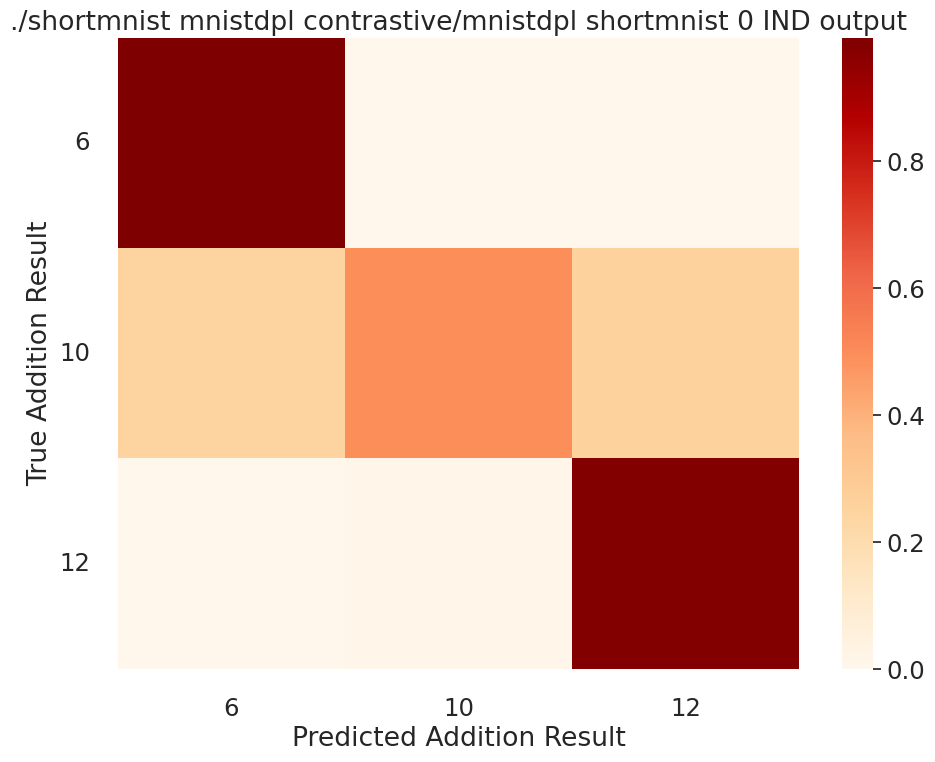

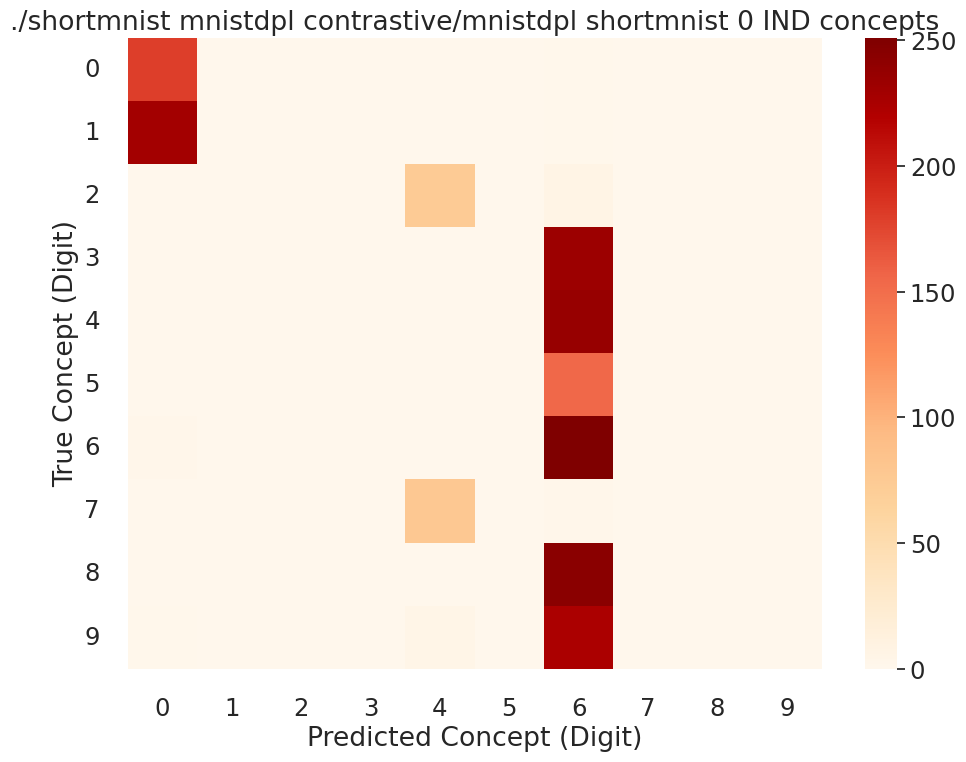

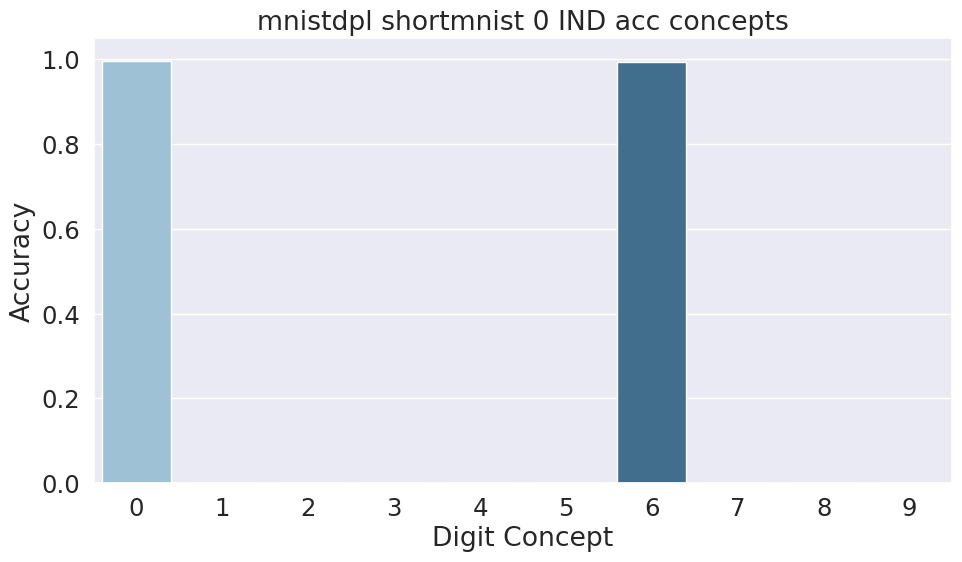

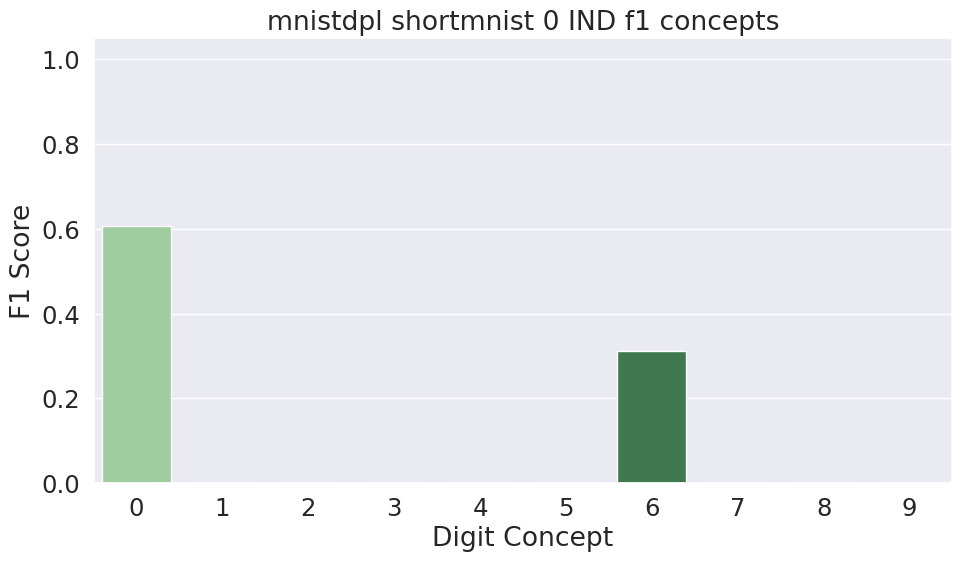

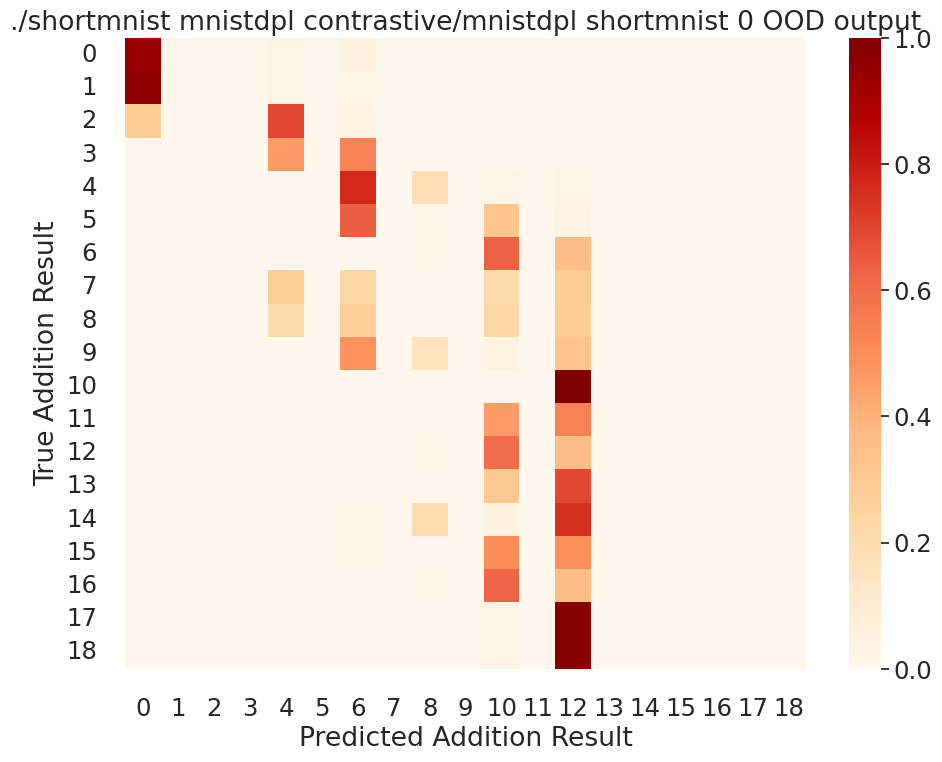

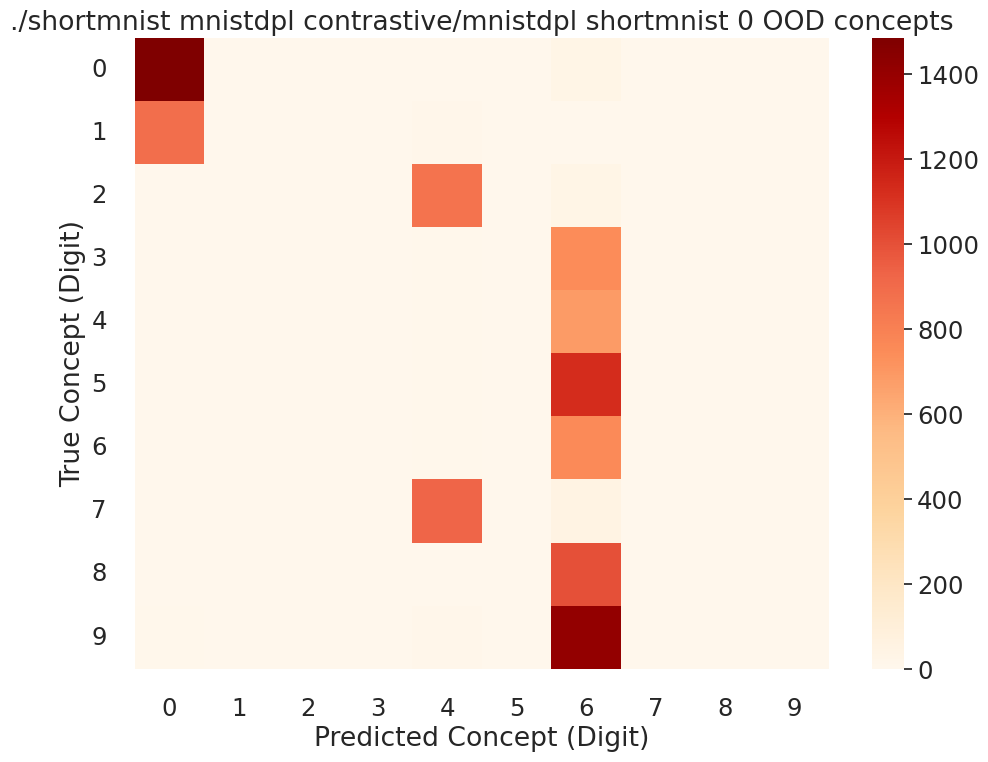

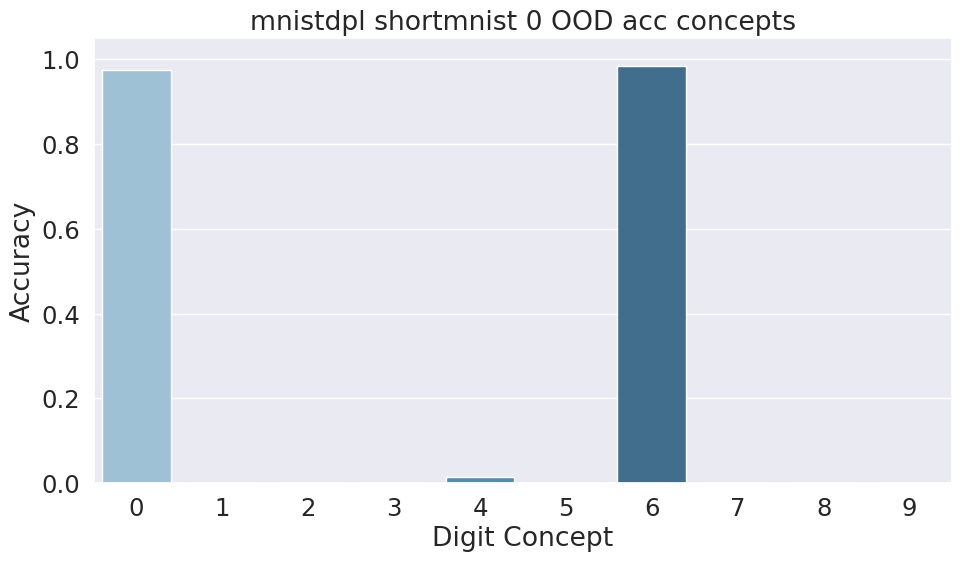

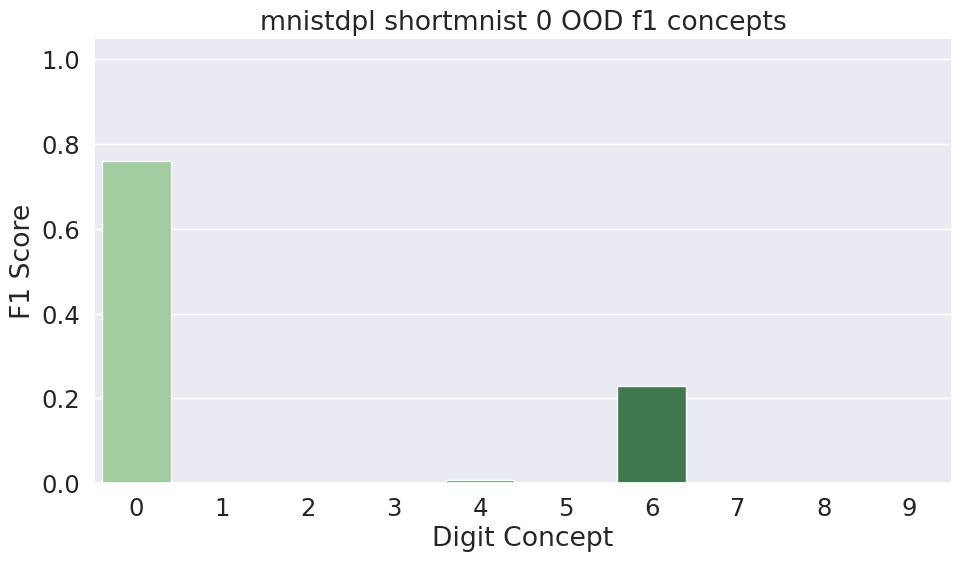

Doing 1 ...
TO ADD _contrastive
Loading ../checkpoints/best_model_shortmnist_mnistdpl_1_contrastive.pth...


100%|██████████| 40/40 [00:00<00:00, 48.44it/s]


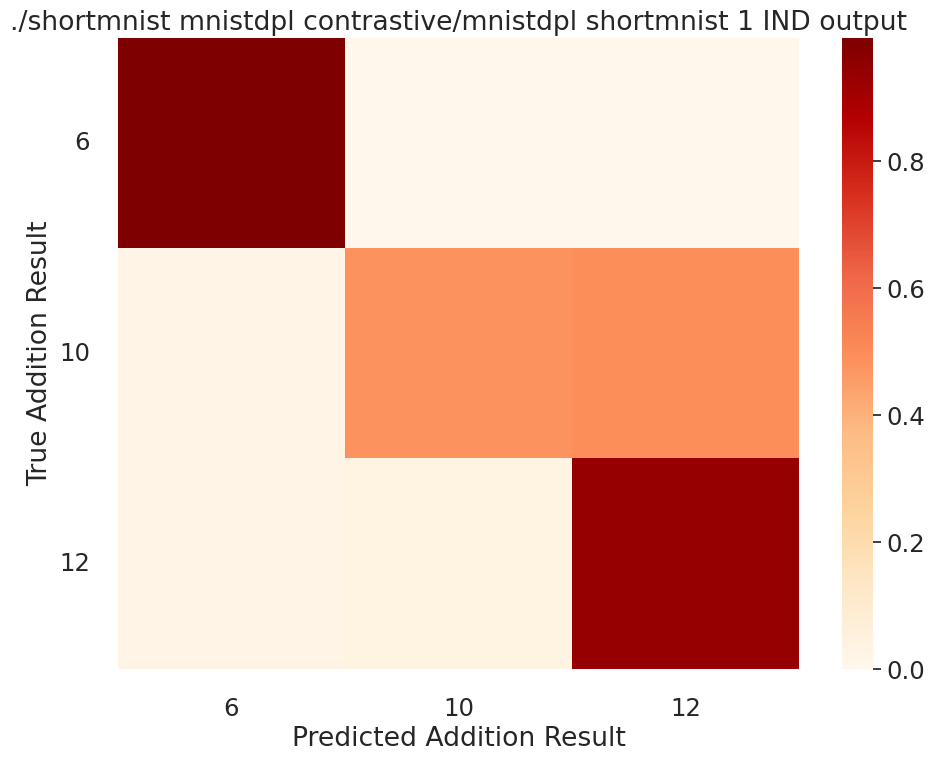

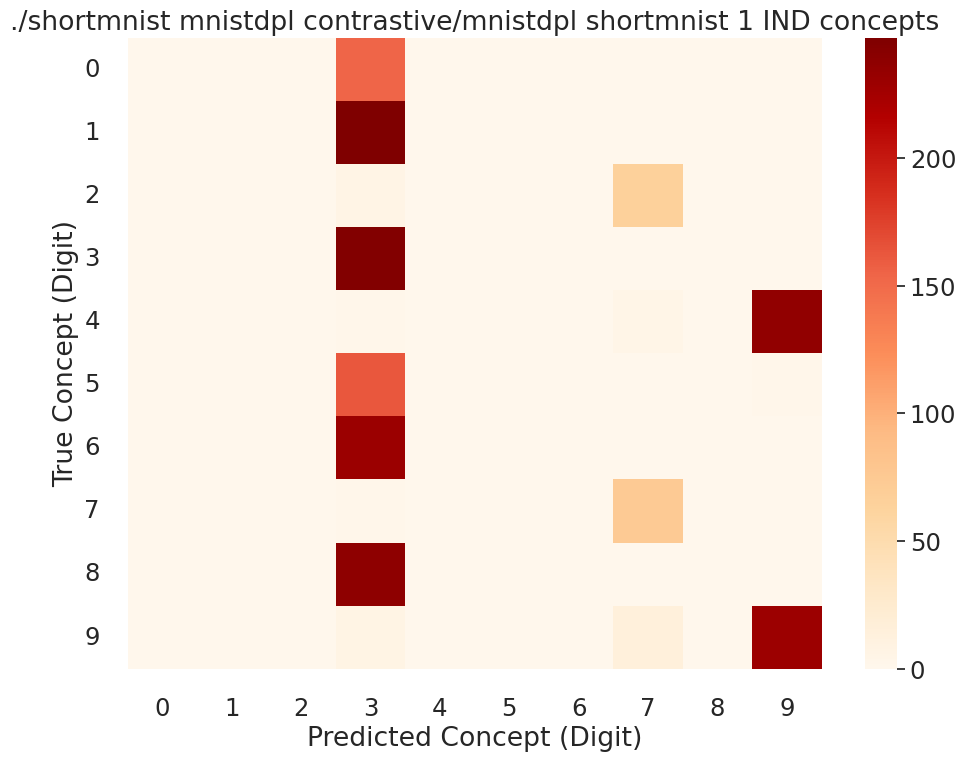

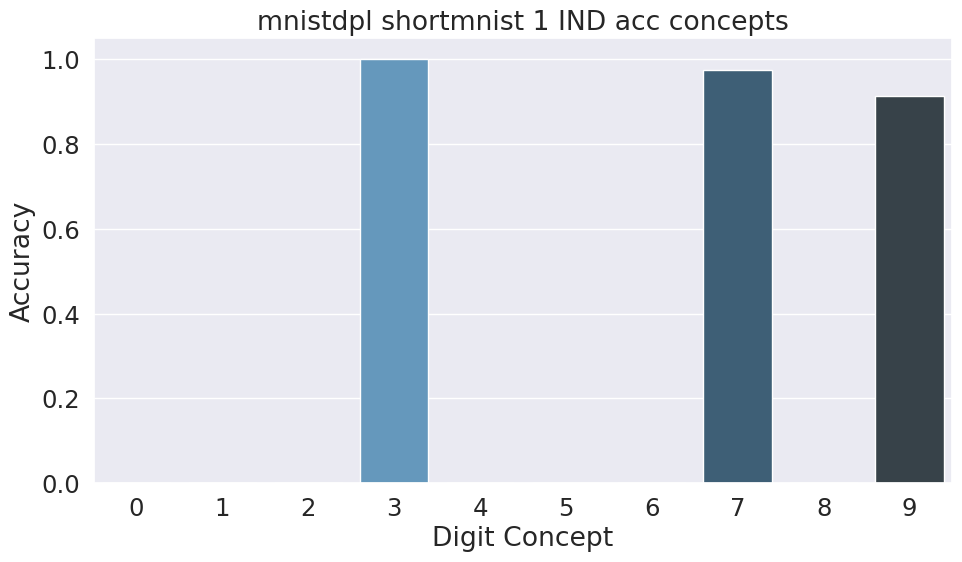

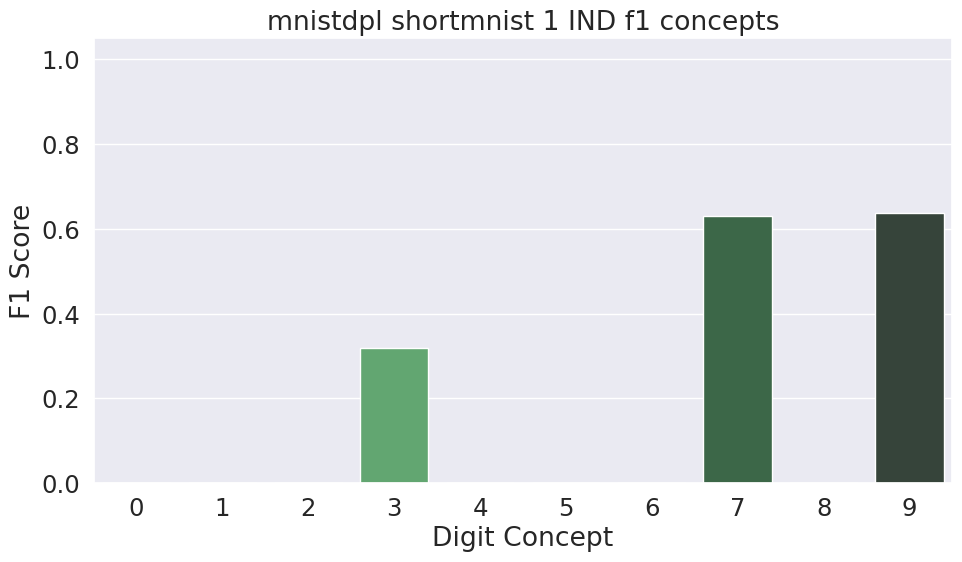

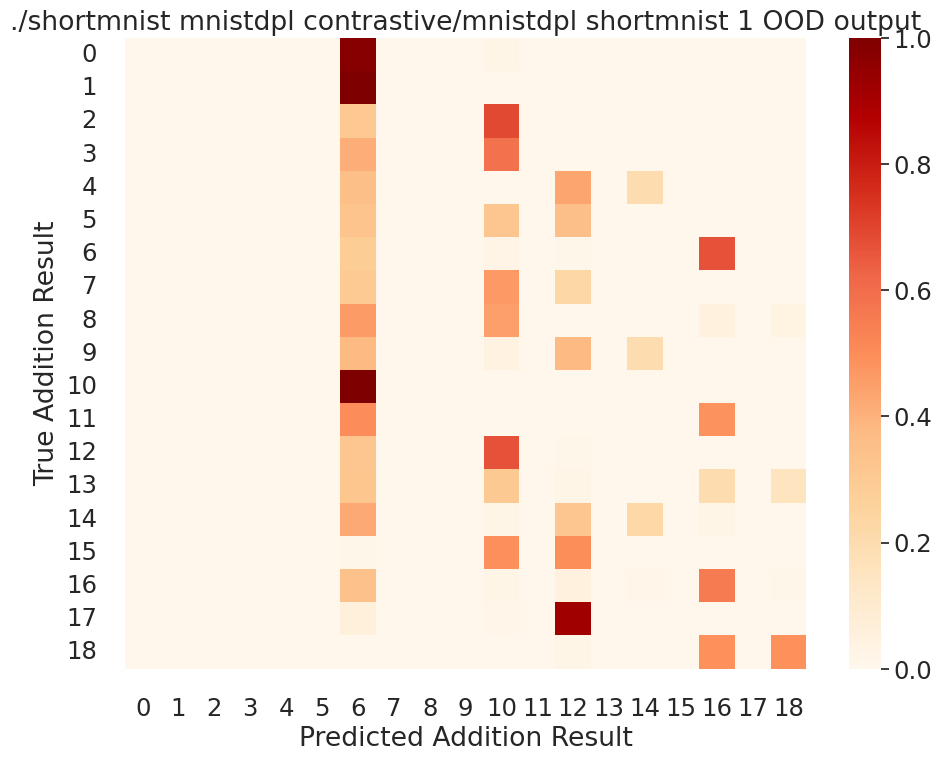

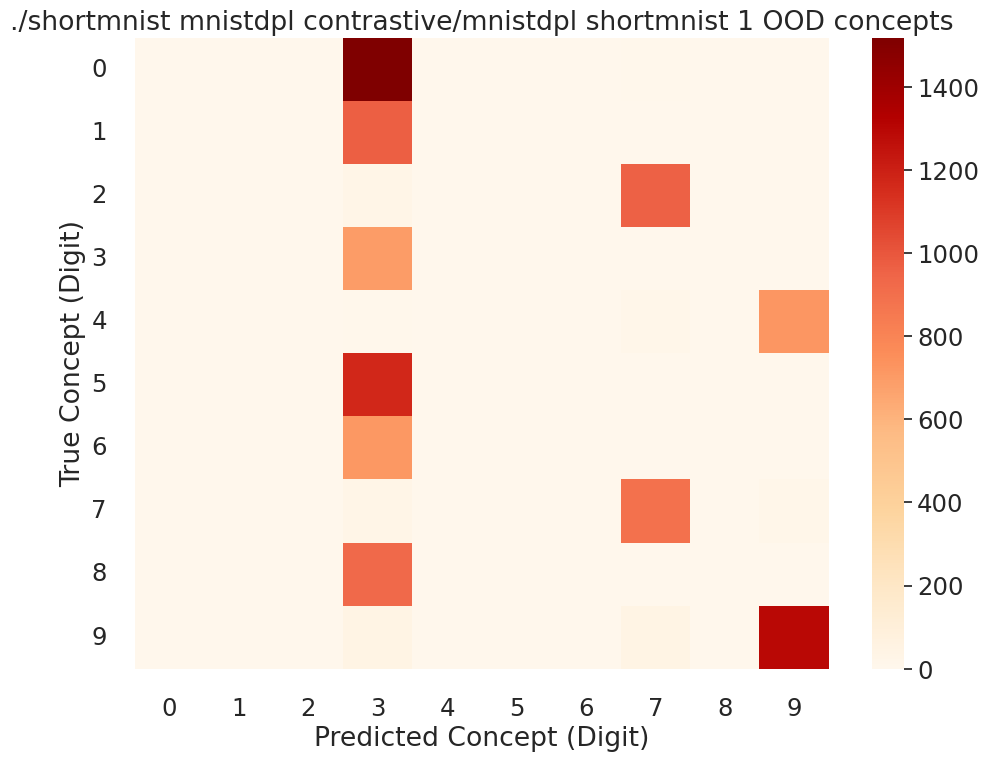

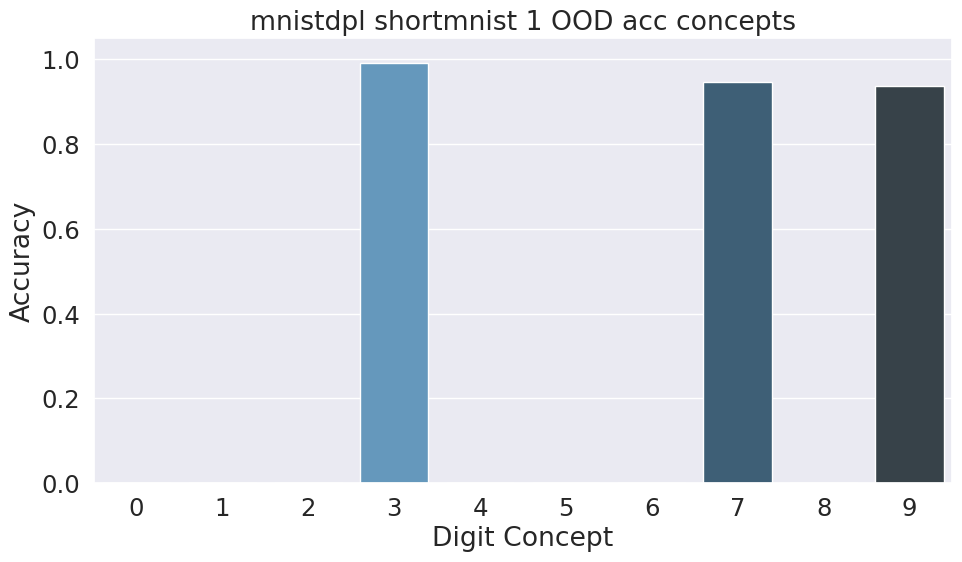

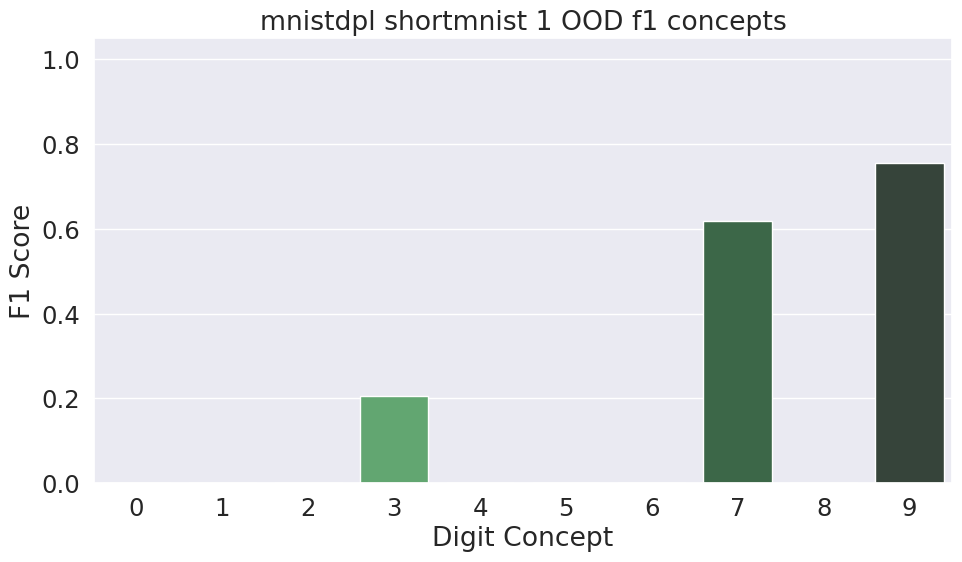

Doing 2 ...
TO ADD _contrastive
Loading ../checkpoints/best_model_shortmnist_mnistdpl_2_contrastive.pth...


100%|██████████| 40/40 [00:00<00:00, 60.47it/s]


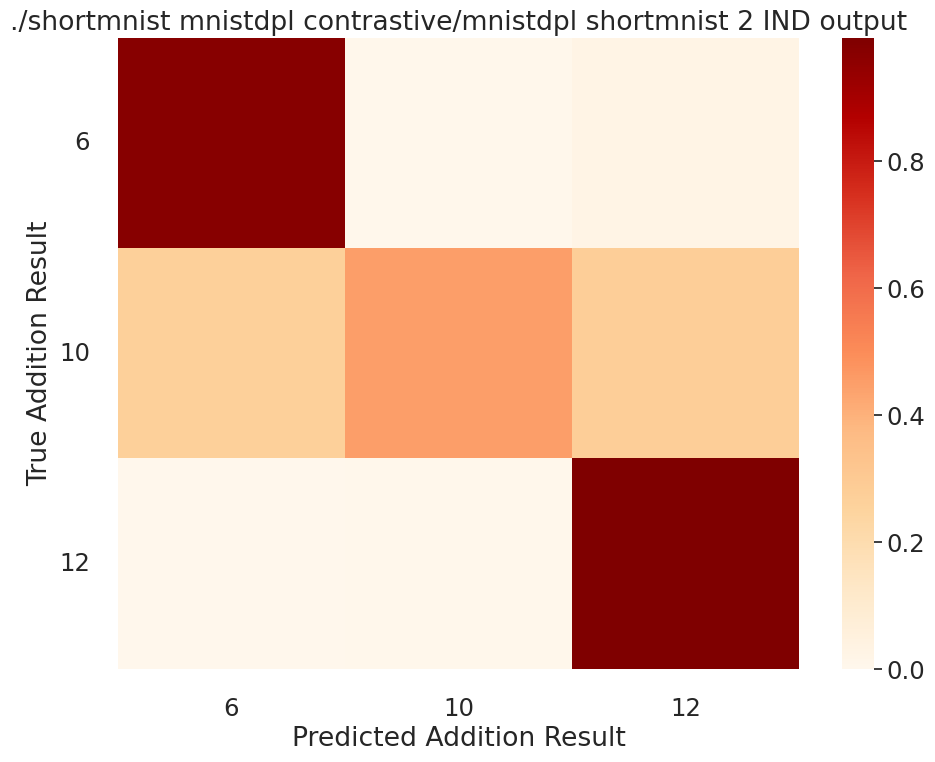

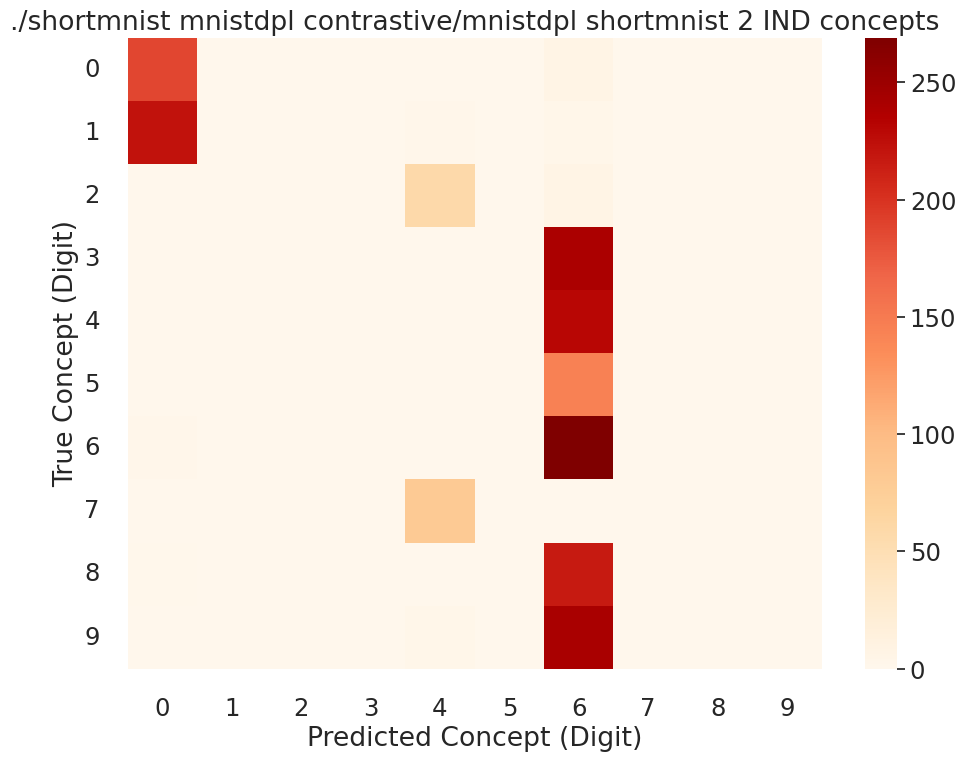

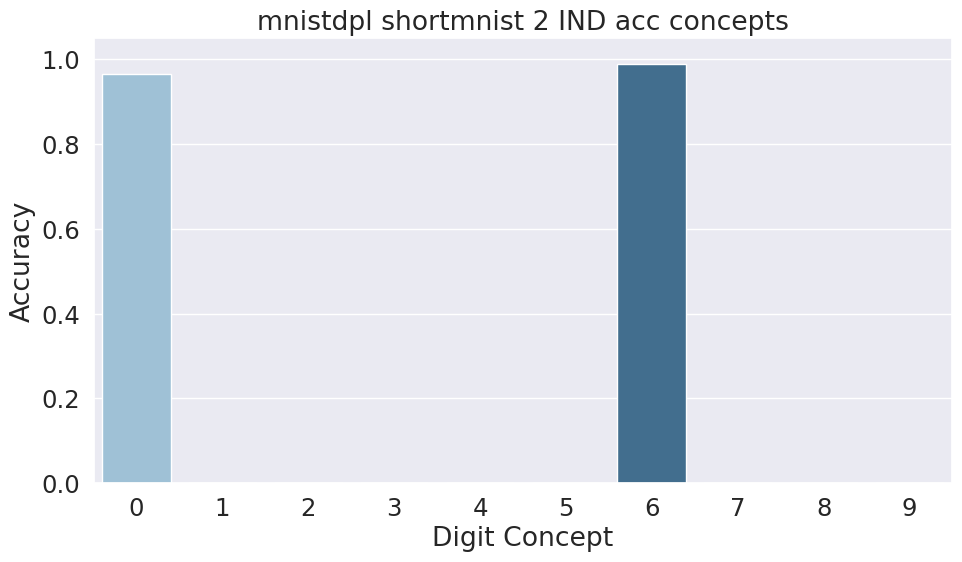

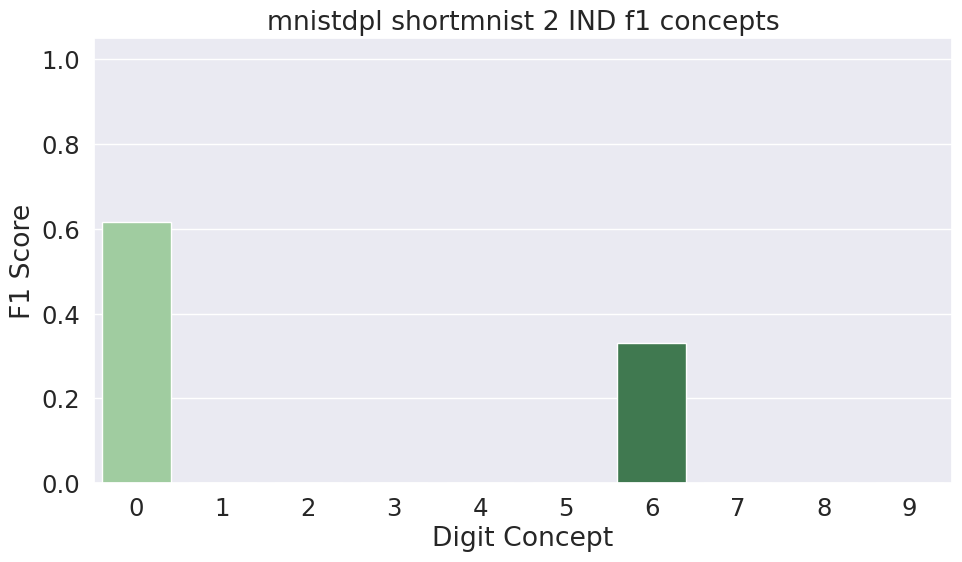

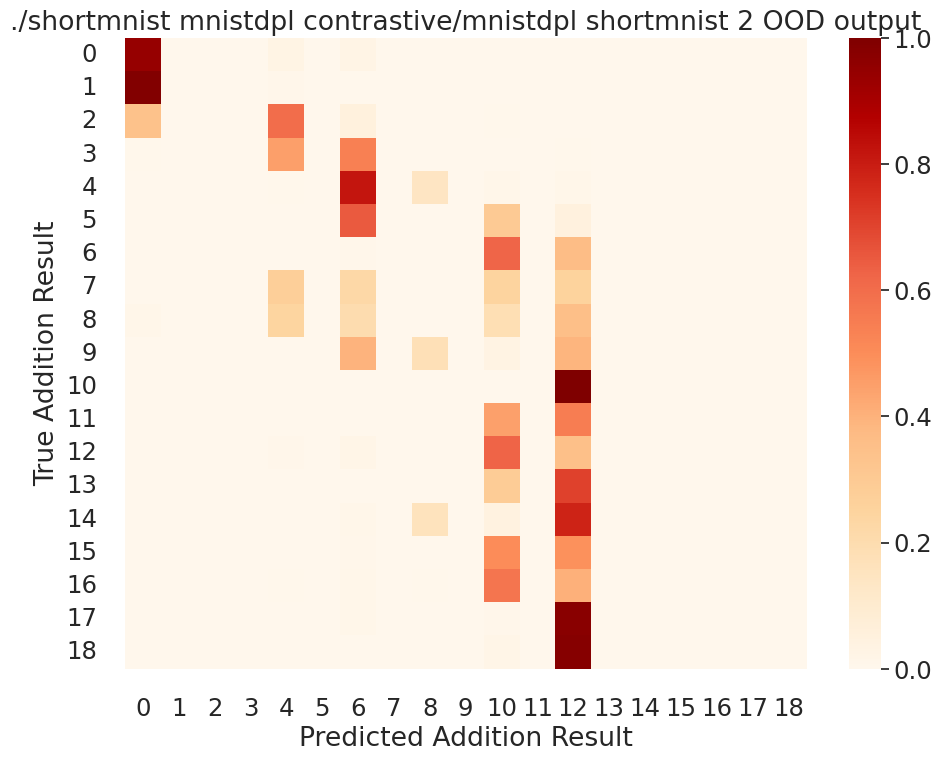

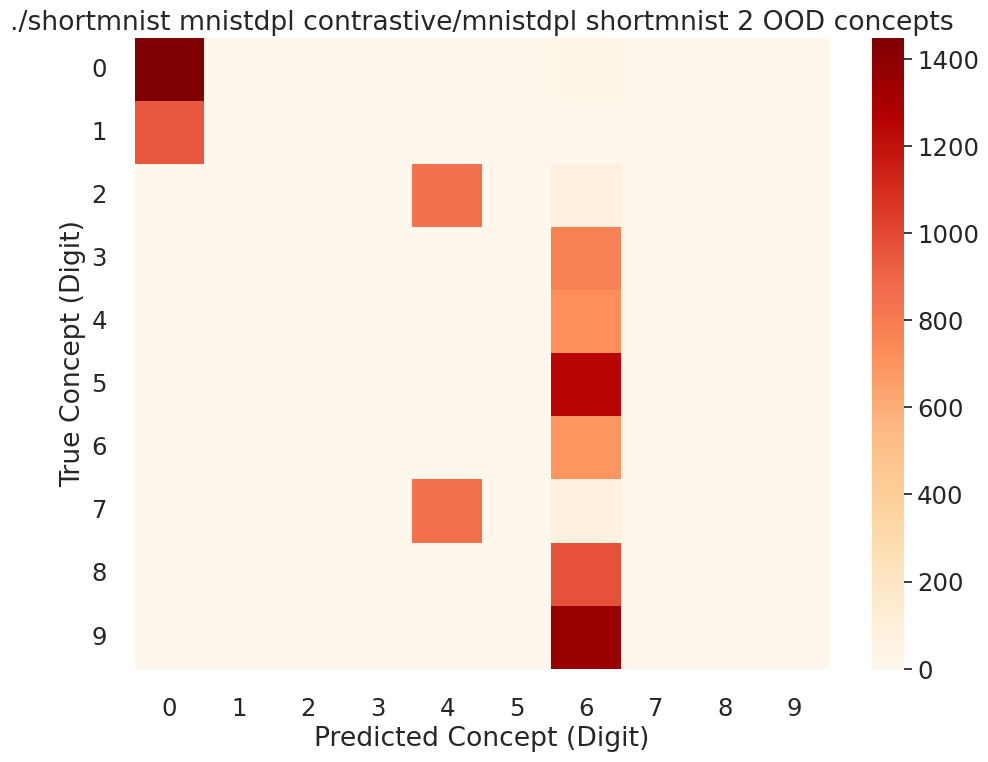

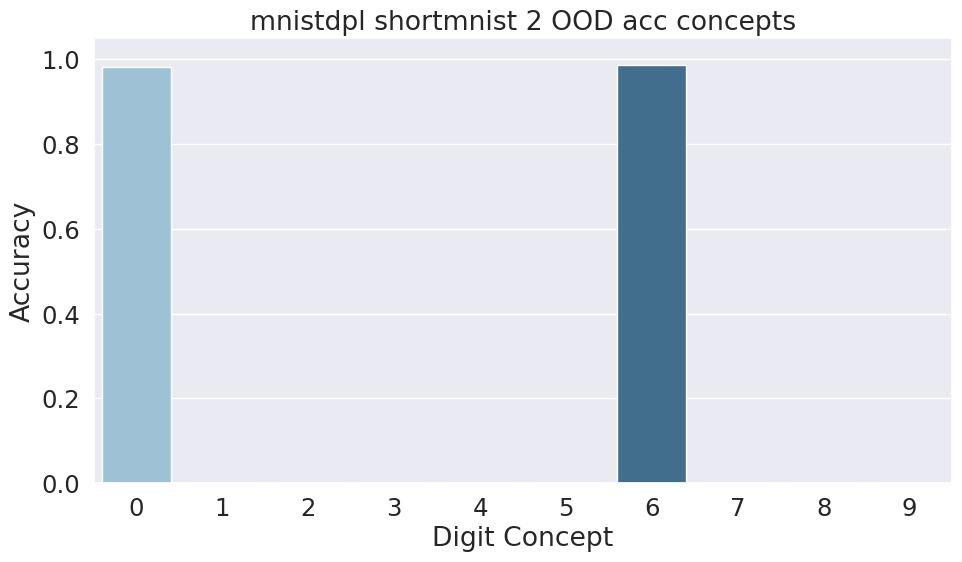

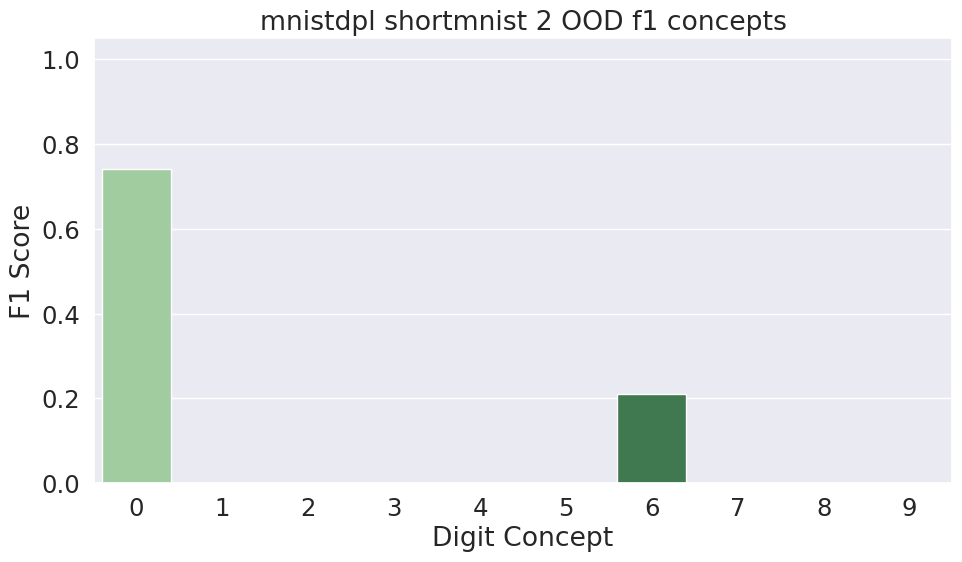

Doing 3 ...
TO ADD _contrastive
Loading ../checkpoints/best_model_shortmnist_mnistdpl_3_contrastive.pth...


100%|██████████| 40/40 [00:00<00:00, 59.63it/s]


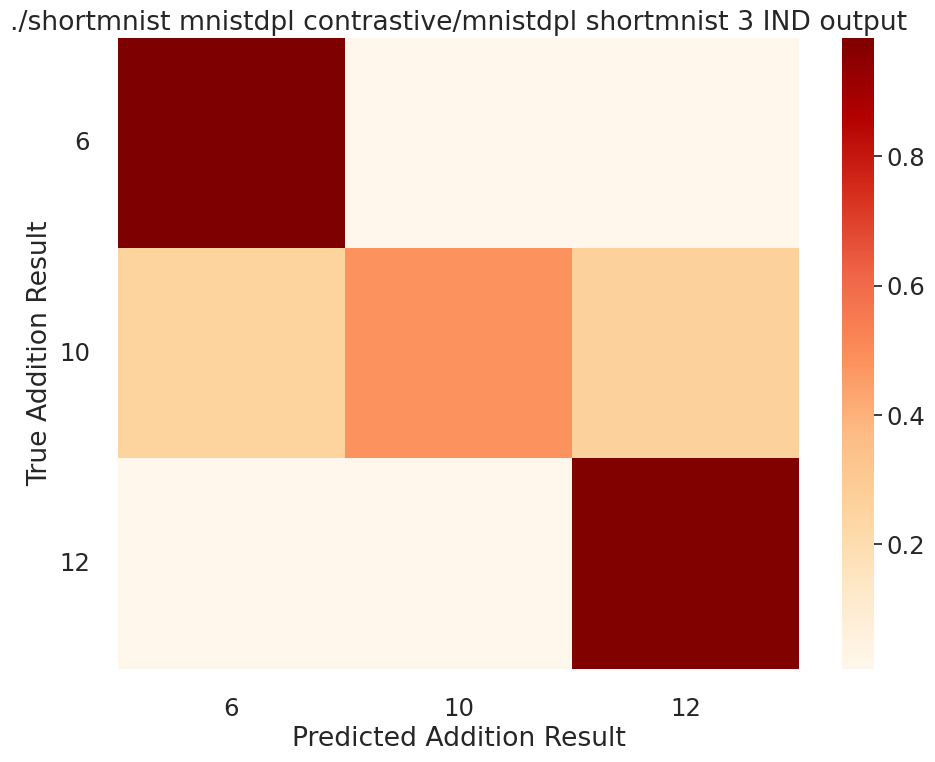

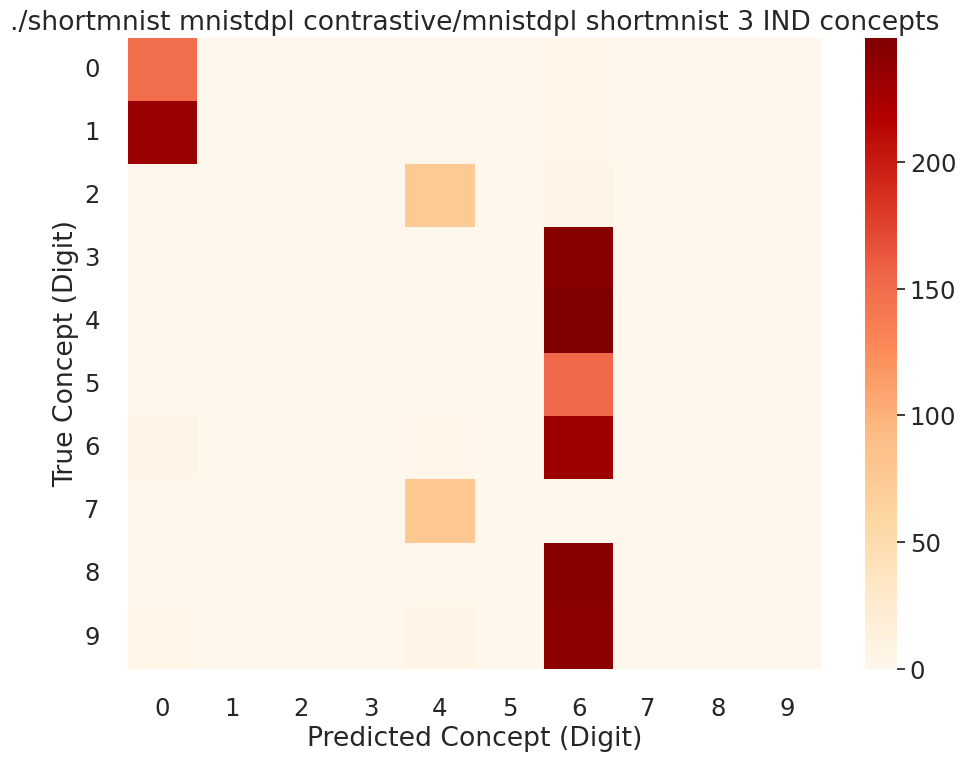

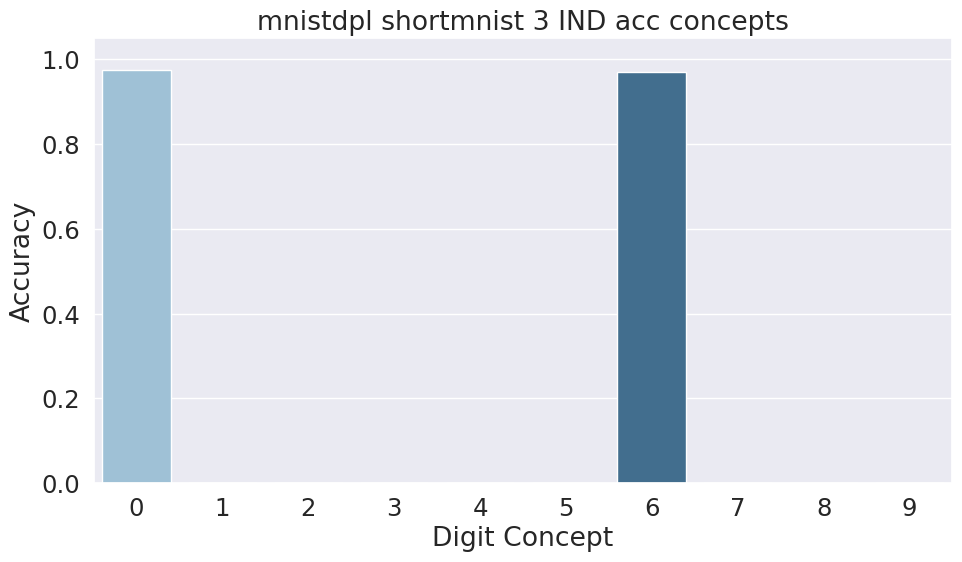

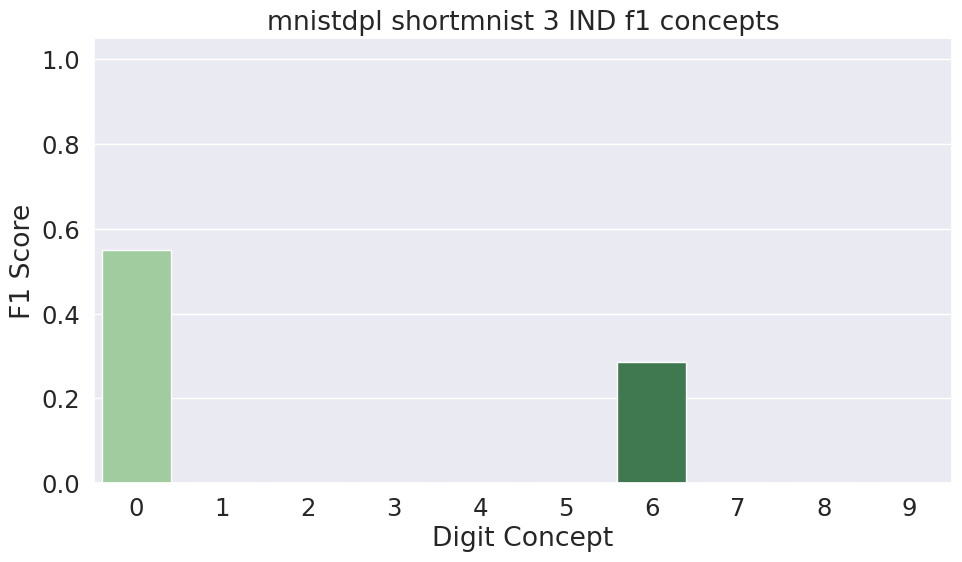

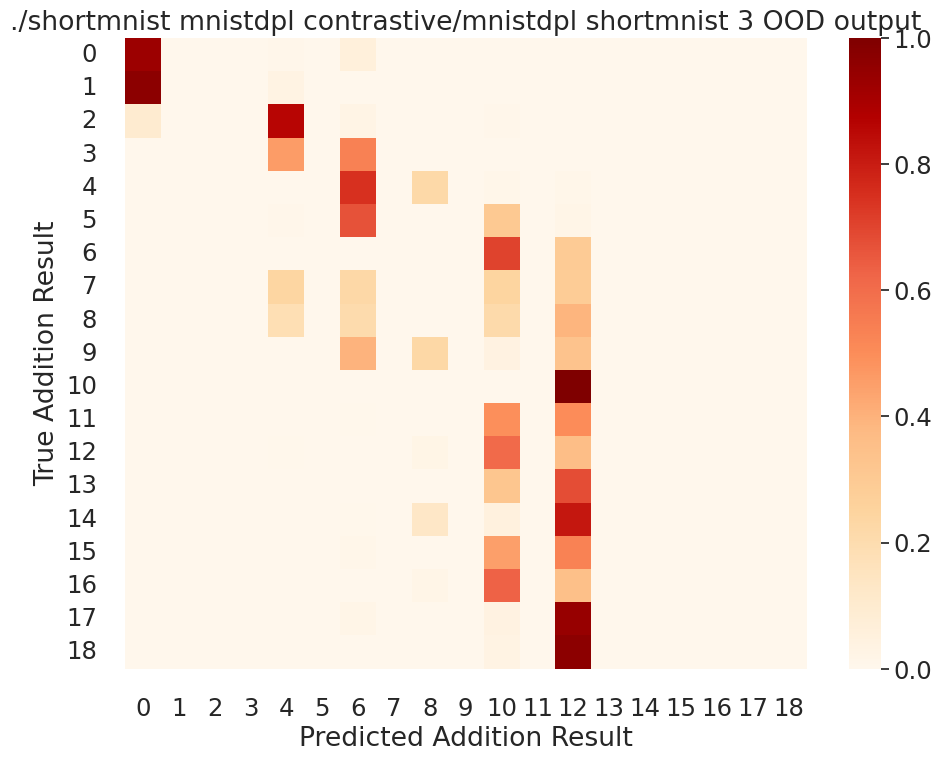

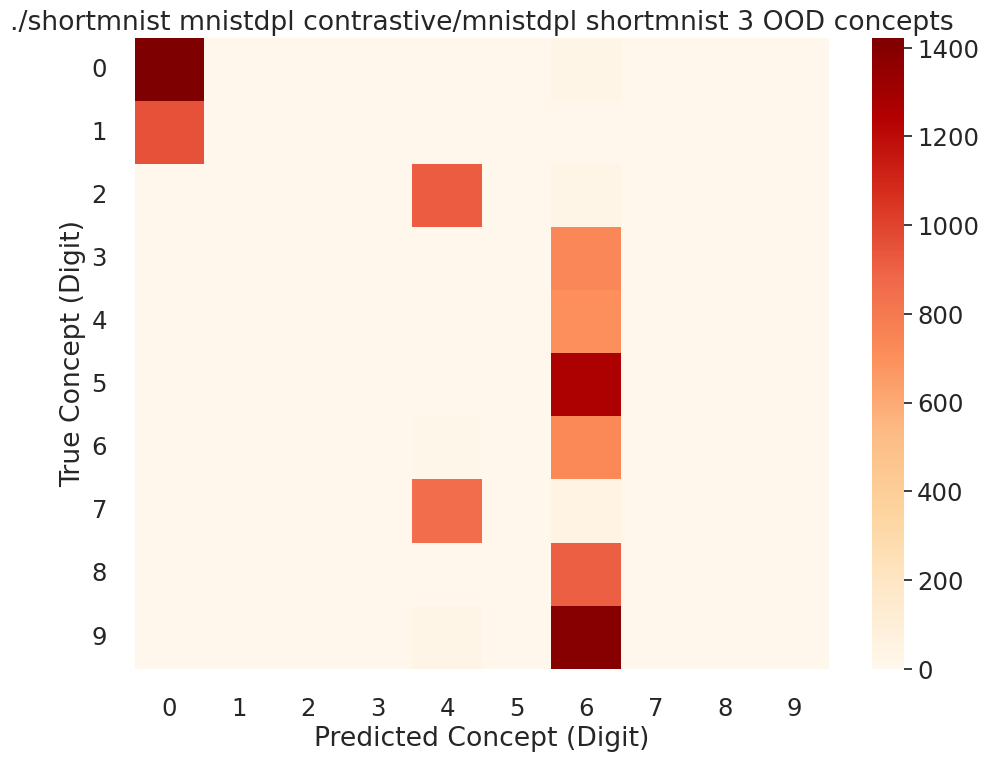

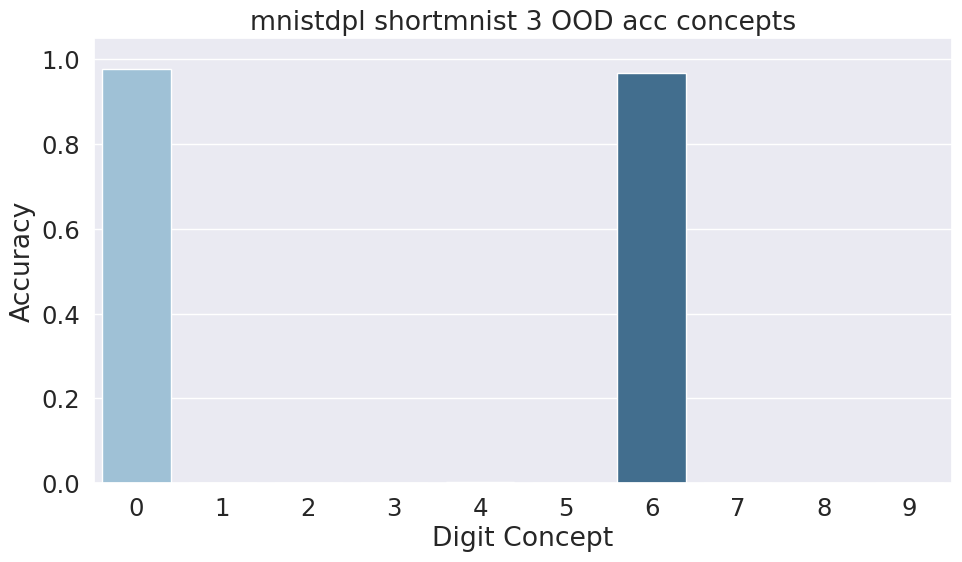

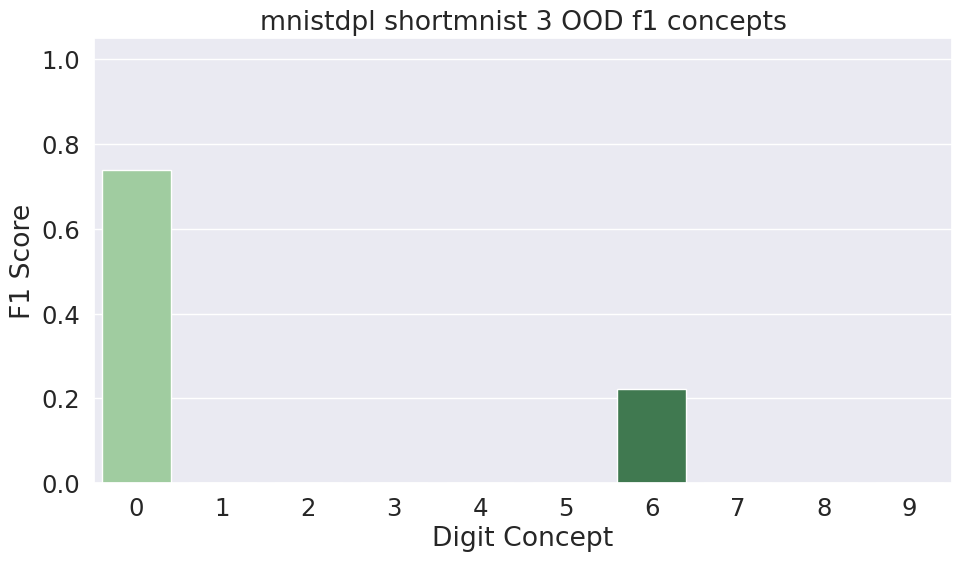


Concept Accuracy (In): 0.24 ± 0.03
Concept Accuracy (OOD): 0.23 ± 0.03

Label Accuracy (In): 0.82 ± 0.01
Label Accuracy (OOD): 0.07 ± 0.01

Concept F1 Macro (In): 0.11 ± 0.03
Concept F1 Macro (OOD): 0.11 ± 0.03

Concept F1 Micro (In): 0.24 ± 0.03
Concept F1 Micro (OOD): 0.23 ± 0.03

Concept F1 Weighted (In): 0.11 ± 0.03
Concept F1 Weighted (OOD): 0.14 ± 0.02

Label F1 Macro (In): 0.80 ± 0.01
Label F1 Macro (OOD): 0.04 ± 0.01

Label F1 Micro (In): 0.82 ± 0.01
Label F1 Micro (OOD): 0.07 ± 0.01

Label F1 Weighted (In): 0.80 ± 0.01
Label F1 Weighted (OOD): 0.04 ± 0.01

Collapse (In): 0.70 ± 0.00
Collapse (OOD): 0.70 ± 0.00

Collapse Hard (In): 1.00 ± 0.00
Collapse Hard (OOD): 1.00 ± 0.00

Avg Nll (In): 2.28 ± 0.00
Avg Nll (OOD): 2.95 ± 0.00


In [25]:
# Reload dataset utilities to pick up path fixes (avoid stale notebook imports)
import importlib
import datasets.utils.mnist_creation as mnist_creation
import datasets.shortcutmnist as shortcutmnist

importlib.reload(mnist_creation)
importlib.reload(shortcutmnist)

# Get loaders
train_loader, val_loader, test_loader = dataset.get_data_loaders()
# Get ood set if it exists
ood_loader = getattr(dataset, "ood_loader", None)

# Evaluate
evaluate(
    model,
    test_loader,
    args.dataset,
    model_name=args.model,
    ood_set=ood_loader,
    ood_set_2=None,
)